# 🔬 Đánh giá Model Fine-tuned


## 1. Cài đặt thư viện


In [2]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict

In [3]:
import os

os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("✅ Môi trường đã sẵn sàng!")


✅ Môi trường đã sẵn sàng!


## 2. Load Model Fine-tuned


In [4]:
# Đường dẫn đến model fine-tuned (output từ notebook 02)
FINETUNED_PATH = "/kaggle/input/deepseek-ocr-finetuned/"

# Kiểm tra đường dẫn
if os.path.exists(FINETUNED_PATH):
    print(f"✅ Tìm thấy model fine-tuned tại: {FINETUNED_PATH}")
else:
    print(f"❌ Không tìm thấy model. Vui lòng kiểm tra đường dẫn!")


✅ Tìm thấy model fine-tuned tại: /kaggle/input/deepseek-ocr-finetuned/


In [5]:
import torch
from unsloth import FastVisionModel
from transformers import AutoModel
from peft import PeftModel
from huggingface_hub import snapshot_download

print("🔄 Đang load model...")

# Bước 1: Tải base model
base_model_path = "/kaggle/working/deepseek_ocr_base"
if not os.path.exists(base_model_path):
    print("⏳ Đang tải base model...")
    snapshot_download("unsloth/DeepSeek-OCR", local_dir=base_model_path)

# Bước 2: Load base model
base_model, tokenizer = FastVisionModel.from_pretrained(
    base_model_path,
    load_in_4bit=True,
    auto_model=AutoModel,
    trust_remote_code=True,
    unsloth_force_compile=True,
    use_gradient_checkpointing="unsloth",
    device_map="cuda:0",
)

# Bước 3: Gắn LoRA adapter đã fine-tune
print("🔄 Đang gắn LoRA adapter...")
model = PeftModel.from_pretrained(base_model, FINETUNED_PATH)

# Chuyển sang chế độ inference
FastVisionModel.for_inference(model)

print("✅ Load model fine-tuned thành công!")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-12-28 07:51:12.634971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766908273.058224     130 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766908273.194762     130 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766908274.229882     130 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766908274.229919     130 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766908274.229921     130 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
🔄 Đang load model...
⏳ Đang tải base model...


.gitattributes: 0.00B [00:00, ?B/s]

README-checkpoint.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2025.12.9: Fast Deepseekocr patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at /kaggle/working/deepseek_ocr_base and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🔄 Đang gắn LoRA adapter...
✅ Load model fine-tuned thành công!


## 3. Chuẩn bị hàm đánh giá


In [9]:
import json
import jiwer
import pandas as pd
from tqdm.notebook import tqdm
from PIL import Image
import shutil
import os
import unicodedata
from unsloth import FastVisionModel

# Cấu hình thư mục đầu ra cho inference
EVAL_OUTPUT_DIR = "/kaggle/working/finetuned_eval_output"
if os.path.exists(EVAL_OUTPUT_DIR):
    shutil.rmtree(EVAL_OUTPUT_DIR)
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

def compute_character_error_rate(reference, hypothesis):
    """Tính CER với chuẩn hóa NFC để so sánh chính xác tiếng Việt"""
    ref = unicodedata.normalize('NFC', reference.strip().lower())
    hyp = unicodedata.normalize('NFC', hypothesis.strip().lower())
    if not ref:
        return 0.0 if not hyp else 1.0
    return jiwer.cer(ref, hyp)

def evaluate_model_on_test(test_root, max_samples=None):
    """
    Đánh giá model bằng cách quét cấu trúc thư mục (folder-based)
    """
    print(f"📂 Đang quét dữ liệu test từ: {test_root}")
    results_list = []
    cer_sum = 0.0
    count = 0
    prompt = "<image>\nFree OCR. "
    
    # Gom tất cả mẫu từ các thư mục con 0, 1, 2...
    all_samples = []
    try:
        subfolders = sorted([f for f in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, f))],
                          key=lambda x: int(x) if x.isdigit() else x)
    except:
        subfolders = sorted([f for f in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, f))])
    
    for folder_name in subfolders:
        folder_path = os.path.join(test_root, folder_name)
        label_file = os.path.join(folder_path, "label.json")
        if os.path.exists(label_file):
            with open(label_file, 'r', encoding='utf-8') as f:
                labels = json.load(f)
            for img_name, text in labels.items():
                img_path = os.path.join(folder_path, img_name)
                if os.path.exists(img_path):
                    all_samples.append({"image": img_path, "text": text, "folder": folder_name})

    if max_samples:
        all_samples = all_samples[:max_samples]
    
    print(f"🚀 Bắt đầu dự đoán {len(all_samples)} mẫu...")
    FastVisionModel.for_inference(model)

    for item in tqdm(all_samples, desc="Evaluating"):
        try:
            img_path = item['image']
            ground_truth = item['text']
            folder = item['folder']
            fname = os.path.basename(img_path)
            
            # Tạo thư mục chứa kết quả cho từng mẫu để tránh lỗi ghi file
            sample_out_dir = os.path.join(EVAL_OUTPUT_DIR, folder, fname)
            os.makedirs(sample_out_dir, exist_ok=True)
            
            model.infer(
                tokenizer,
                prompt=prompt,
                image_file=img_path,
                output_path=sample_out_dir,
                base_size=1024,
                image_size=640,
                crop_mode=True,
                save_results=True,
                test_compress=False
            )
            
            # Đọc nội dung dự đoán từ file Markdown sinh ra
            pred_file = os.path.join(sample_out_dir, "result.mmd")
            prediction = ""
            if os.path.exists(pred_file):
                with open(pred_file, 'r', encoding='utf-8') as f:
                    prediction = f.read().strip()
            
            cer = compute_character_error_rate(ground_truth, prediction)
            cer_sum += cer
            count += 1
            
            results_list.append({
                "folder": folder,
                "image": fname,
                "ground_truth": ground_truth,
                "prediction": prediction,
                "cer": cer
            })
        except Exception:
            continue
    
    avg_cer = cer_sum / count if count > 0 else 0
    return pd.DataFrame(results_list), avg_cer, count

print("✅ Đã chuẩn bị hàm đánh giá cấu trúc thư mục!")

✅ Đã chuẩn bị hàm đánh giá cấu trúc thư mục!


## 4. Chạy đánh giá


In [10]:
TEST_DATA_ROOT = "/kaggle/input/uit-uwdb-line/UIT_HWDB_line/test_data"

df_finetuned, avg_cer_finetuned, n_samples = evaluate_model_on_test(
    TEST_DATA_ROOT, 
    max_samples=None 
)

print(f"\n📊 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT:")
print(f"🔹 Tổng số mẫu thực tế: {n_samples}")
print(f"🔹 Average CER: {avg_cer_finetuned:.4f} ({(avg_cer_finetuned*100):.2f}%)")

RESULTS_CSV = "/kaggle/working/finetuned_results.csv"
df_finetuned.to_csv(RESULTS_CSV, index=False, encoding='utf-8-sig')
print(f"💾 Đã lưu file kết quả: {RESULTS_CSV}")

📂 Đang quét dữ liệu test từ: /kaggle/input/uit-uwdb-line/UIT_HWDB_line/test_data
🚀 Bắt đầu dự đoán 201 mẫu...


Evaluating:   0%|          | 0/201 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
Thứ trưởng Bộ Tài nguyên và môi trường Đặng Hùng Võ đã ra đã với 
===============save results:===============



image: 0it [00:00, ?it/s]

other: 0it [00:00, ?it/s]


...

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
NV2, NV3. Quan trọng là họ đã nỗ lực hết sức để khẳng định mình. Đó là ý nghĩa văn nguyên 
===============save results:===============



image: 0it [00:00, ?it/s]

other: 0it [00:00, ?it/s]


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
của các kỳ thi, và cũng là bản chất của thành công. 
===============save results:===============



image: 0it [00:00, ?it/s]

other: 0it [00:00, ?it/s]


📊 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT:
🔹 Tổng số mẫu thực tế: 201
🔹 Average CER: 0.1611 (16.11%)
💾 Đã lưu file kết quả: /kaggle/working/finetuned_results.csv


## 5. Kết quả tổng hợp


In [11]:
# Hiển thị kết quả
print("\n" + "="*55)
print(f"{'📊 KẾT QUẢ ĐÁNH GIÁ MODEL FINE-TUNED':^55}")
print("="*55)
print(f"  Số mẫu đánh giá  : {n_samples}")
print(f"  Average CER      : {avg_cer_finetuned:.4f}")
print(f"  Tỷ lệ lỗi ký tự  : {avg_cer_finetuned*100:.2f}%")
print("="*55)

# Thống kê chi tiết
print(f"\n📈 Chi tiết phân phối CER:")
print(f"   Median CER : {df_finetuned['cer'].median():.4f}")
print(f"   Std Dev    : {df_finetuned['cer'].std():.4f}")  
print(f"   Min CER    : {df_finetuned['cer'].min():.4f}")
print(f"   Max CER    : {df_finetuned['cer'].max():.4f}")

# Đếm mẫu hoàn hảo (CER = 0)
perfect = (df_finetuned['cer'] == 0).sum()
print(f"\n🎯 Số mẫu nhận dạng hoàn hảo: {perfect}/{n_samples} ({perfect/n_samples*100:.1f}%)")



          📊 KẾT QUẢ ĐÁNH GIÁ MODEL FINE-TUNED          
  Số mẫu đánh giá  : 201
  Average CER      : 0.1611
  Tỷ lệ lỗi ký tự  : 16.11%

📈 Chi tiết phân phối CER:
   Median CER : 0.1000
   Std Dev    : 0.1825
   Min CER    : 0.0000
   Max CER    : 1.3333

🎯 Số mẫu nhận dạng hoàn hảo: 28/201 (13.9%)


## 6. Trực quan hóa


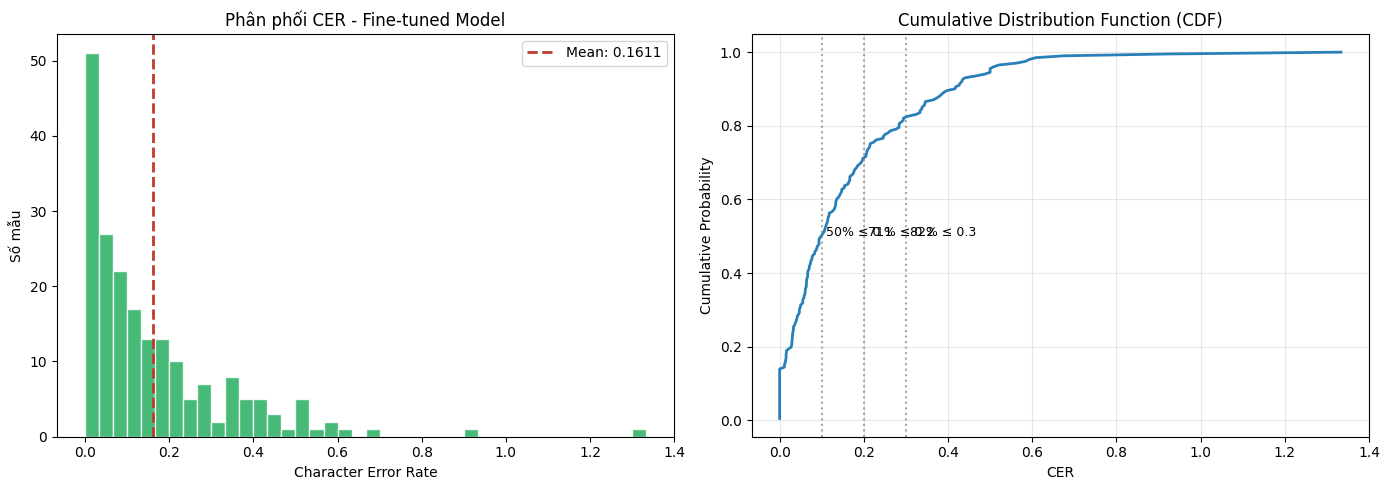

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram CER
axes[0].hist(df_finetuned['cer'], bins=40, color='#27AE60', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_cer_finetuned, color='#C0392B', linestyle='--', linewidth=2,
                label=f'Mean: {avg_cer_finetuned:.4f}')
axes[0].set_xlabel('Character Error Rate')
axes[0].set_ylabel('Số mẫu')
axes[0].set_title('Phân phối CER - Fine-tuned Model')
axes[0].legend()

# CDF
sorted_cer = np.sort(df_finetuned['cer'])
cdf = np.arange(1, len(sorted_cer) + 1) / len(sorted_cer)
axes[1].plot(sorted_cer, cdf, color='#2980B9', linewidth=2)
axes[1].set_xlabel('CER')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Cumulative Distribution Function (CDF)')
axes[1].grid(True, alpha=0.3)

# Đánh dấu các mốc quan trọng
for threshold in [0.1, 0.2, 0.3]:
    pct = (sorted_cer <= threshold).sum() / len(sorted_cer) * 100
    axes[1].axvline(threshold, color='gray', linestyle=':', alpha=0.7)
    axes[1].text(threshold + 0.01, 0.5, f'{pct:.0f}% ≤ {threshold}', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Hiển thị mẫu kết quả


In [13]:
def visualize_predictions(df, num_best=3, num_worst=3):
    """Hiển thị kết quả tốt nhất và tệ nhất"""
    
    # === TOP TỐT NHẤT ===
    best = df.nsmallest(num_best, 'cer')
    print("="*70)
    print(f"🌟 TOP {num_best} MẪU NHẬN DẠNG TỐT NHẤT")
    print("="*70)
    
    for _, row in best.iterrows():
        img_name = os.path.basename(row['image'])
        folder = os.path.basename(os.path.dirname(row['image']))
        
        print(f"\n📷 {folder}/{img_name} | CER: {row['cer']:.2%}")
        print(f"   ✅ GT  : {row['ground_truth']}")
        print(f"   🤖 Pred: {row['prediction']}")
        
        if os.path.exists(row['image']):
            img = Image.open(row['image']).convert('RGB')
            plt.figure(figsize=(12, 2))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
        print("-"*70)
    
    # === TOP TỆ NHẤT ===
    worst = df.nlargest(num_worst, 'cer')
    print("\n" + "="*70)
    print(f"🚨 TOP {num_worst} MẪU NHẬN DẠNG TỆ NHẤT")
    print("="*70)
    
    for _, row in worst.iterrows():
        img_name = os.path.basename(row['image'])
        folder = os.path.basename(os.path.dirname(row['image']))
        
        print(f"\n📷 {folder}/{img_name} | CER: {row['cer']:.2%}")
        print(f"   ✅ GT  : {row['ground_truth']}")
        print(f"   🤖 Pred: {row['prediction']}")
        
        if os.path.exists(row['image']):
            img = Image.open(row['image']).convert('RGB')
            plt.figure(figsize=(12, 2))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
        print("-"*70)

# Hiển thị
visualize_predictions(df_finetuned, num_best=4, num_worst=4)


🌟 TOP 4 MẪU NHẬN DẠNG TỐT NHẤT

📷 /11.jpg | CER: 0.00%
   ✅ GT  : Chưa kể để doanh nghiệp và người dân " nói chuyện " với nhau như
   🤖 Pred: chưa kể để doanh nghiệp và người dân " nói chuyện " với nhau như
----------------------------------------------------------------------

📷 /21.jpg | CER: 0.00%
   ✅ GT  : chúng ta cần thay đổi trong quan điểm, không nên để hệ thống hành chính
   🤖 Pred: chúng ta cần thay đổi trong quan điểm, không nên để hệ thống hành chính
----------------------------------------------------------------------

📷 /24.jpg | CER: 0.00%
   ✅ GT  : đất.
   🤖 Pred: đất.
----------------------------------------------------------------------

📷 /25.jpg | CER: 0.00%
   ✅ GT  : Ngay cả trường hợp ta không qui định, người dân và doanh nghiệp vẫn thực hiện
   🤖 Pred: Ngay cả trường hợp ta không qui định, người dân và doanh nghiệp vẫn thực hiện
----------------------------------------------------------------------

🚨 TOP 4 MẪU NHẬN DẠNG TỆ NHẤT

📷 /7.jpg | CER: 133.33%
   ✅ 